# DMP Label Evaluation

Compares LLM-predicted labels (`data/llmlabeled/*_<model>.json`) against manually labeled ground truth (`data/manuallabeled/*_dmp.json`).

Shows:
- Per-sample accuracy
- Confusion matrix (aggregate across all samples)
- Precision / Recall / F1 per label
- Which blocks were wrong, and what they actually said

In [1]:
import sys
print(sys.executable)

c:\Users\Nahid\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import sys
sys.path.insert(0, "..")

from evaluate import extract_gold, evaluate_sample, match, tokenize, LABELS, SHORT, LLM_DIR, MANUAL_DIR, LLM_SUFFIX
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="dark", palette="muted")
plt.rcParams["figure.facecolor"] = "#1e1e2e"
plt.rcParams["axes.facecolor"]   = "#1e1e2e"
plt.rcParams["text.color"]       = "white"
plt.rcParams["axes.labelcolor"]  = "white"
plt.rcParams["xtick.color"]      = "white"
plt.rcParams["ytick.color"]      = "white"
plt.rcParams["axes.edgecolor"]   = "#444455"
plt.rcParams["grid.color"]       = "#333344"
print(f"Ready. Evaluating files matching: *{LLM_SUFFIX}.json")

Ready. Evaluating files matching: *_llama3.3-70b.json


## 1 — Load all samples and collect predictions

In [3]:
samples = sorted(MANUAL_DIR.glob("*_dmp.json"))

total_confusion = defaultdict(lambda: defaultdict(int))
per_sample_rows = []
all_errors      = []

for manual_path in samples:
    stem      = manual_path.stem.replace("_dmp", "")
    pred_path = LLM_DIR / f"{stem}{LLM_SUFFIX}.json"
    if not pred_path.exists():
        continue

    gold      = extract_gold(manual_path)
    confusion = evaluate_sample(pred_path, gold)

    blocks = json.loads(pred_path.read_text(encoding="utf-8"))
    for block in blocks:
        true_lbl = match(block["text"], gold)
        if true_lbl is None:
            continue
        pred_lbl = block.get("label", "answer.text")
        total_confusion[true_lbl][pred_lbl] += 1
        if true_lbl != pred_lbl:
            all_errors.append({
                "sample": stem,
                "text":   block["text"][:120],
                "true":   true_lbl,
                "pred":   pred_lbl,
                "page":   block.get("page", "-"),
            })

    tp = sum(confusion.get(l, {}).get(l, 0) for l in LABELS)
    n  = sum(sum(v.values()) for v in confusion.values())
    per_sample_rows.append({"sample": stem, "matched": n, "correct": tp, "accuracy": tp / n if n else 0})

df_samples = pd.DataFrame(per_sample_rows)
df_errors  = pd.DataFrame(all_errors)

print(f"Total matched blocks : {df_samples['matched'].sum()}")
print(f"Total errors         : {len(df_errors)}")
df_samples

Total matched blocks : 726
Total errors         : 20


,sample,matched,correct,accuracy
0,sample10,68,65,0.955882
1,sample1,78,76,0.974359
2,sample2,171,165,0.964912
3,sample3,69,68,0.985507
4,sample4,78,78,1.000000
5,sample5,80,79,0.987500
6,sample6,21,18,0.857143
7,sample7,17,16,0.941176
8,sample8,59,57,0.966102
9,sample9,85,84,0.988235


## 2 — Per-sample accuracy

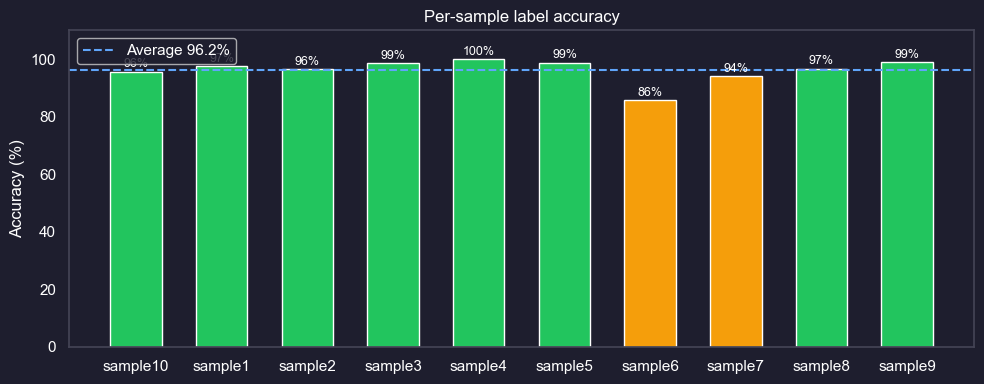

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ["#22c55e" if a >= 0.95 else "#f59e0b" if a >= 0.85 else "#ef4444"
          for a in df_samples["accuracy"]]

bars = ax.bar(df_samples["sample"], df_samples["accuracy"] * 100, color=colors, width=0.6)
ax.axhline(df_samples["accuracy"].mean() * 100, color="#60a5fa", linestyle="--", linewidth=1.5,
           label=f"Average {df_samples['accuracy'].mean()*100:.1f}%")

for bar, row in zip(bars, df_samples.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{row.accuracy*100:.0f}%", ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-sample label accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## 3 — Confusion matrix (all samples combined)

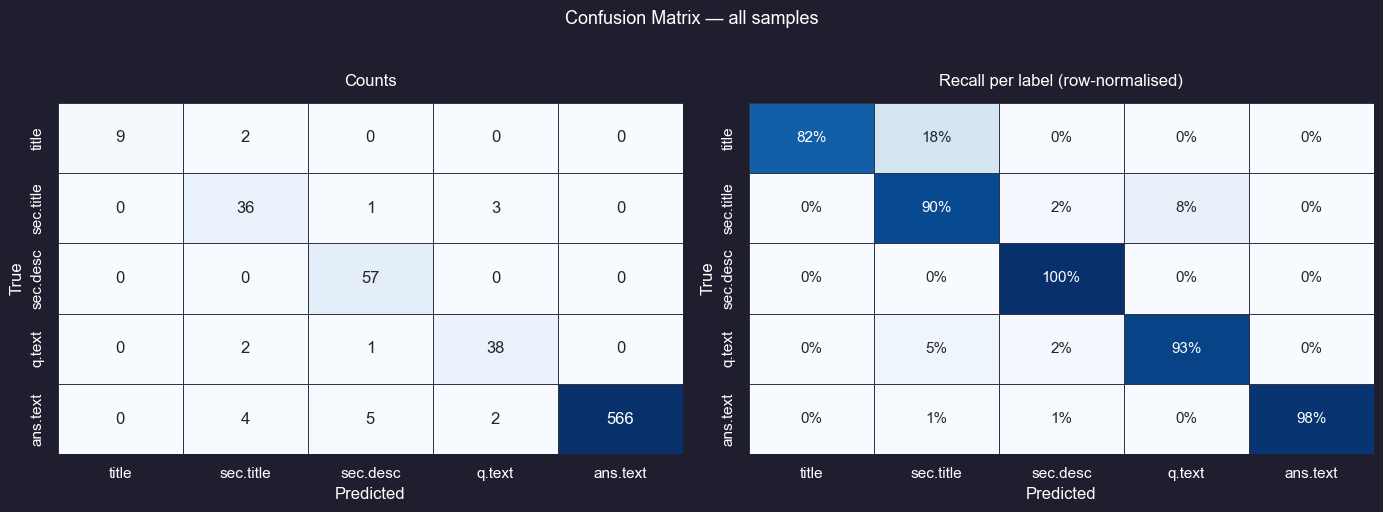

In [5]:
# Build DataFrame from total_confusion
matrix = pd.DataFrame(
    [[total_confusion.get(true, {}).get(pred, 0) for pred in LABELS] for true in LABELS],
    index=SHORT, columns=SHORT
)

# Normalize each row → recall per label
matrix_norm = matrix.div(matrix.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            linecolor="#333344", ax=axes[0], cbar=False,
            annot_kws={"size": 12})
axes[0].set_title("Counts", pad=12)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Normalised (row = recall)
sns.heatmap(matrix_norm, annot=True, fmt=".0%", cmap="Blues", linewidths=0.5,
            linecolor="#333344", ax=axes[1], cbar=False, vmin=0, vmax=1,
            annot_kws={"size": 11})
axes[1].set_title("Recall per label (row-normalised)", pad=12)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.suptitle("Confusion Matrix — all samples", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 4 — Precision / Recall / F1 per label

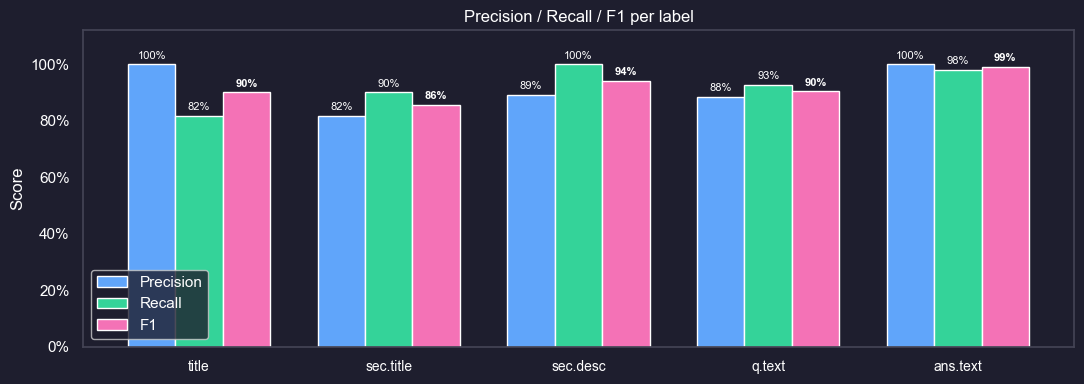

,precision,recall,f1,support
label,,,,
title,100.0%,81.8%,90.0%,11
section.title,81.8%,90.0%,85.7%,40
section.description,89.1%,100.0%,94.2%,57
question.text,88.4%,92.7%,90.5%,41
answer.text,100.0%,98.1%,99.0%,577


In [6]:
rows = []
for lbl in LABELS:
    tp = total_confusion.get(lbl, {}).get(lbl, 0)
    fp = sum(total_confusion.get(other, {}).get(lbl, 0) for other in LABELS if other != lbl)
    fn = sum(v for pred, v in total_confusion.get(lbl, {}).items() if pred != lbl)
    support = tp + fn
    p  = tp / (tp + fp) if (tp + fp) else 0.0
    r  = tp / support   if support   else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    rows.append({"label": lbl, "precision": p, "recall": r, "f1": f1, "support": support})

df_f1 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(LABELS))
w = 0.25

ax.bar([i - w for i in x], df_f1["precision"], width=w, label="Precision", color="#60a5fa")
ax.bar([i      for i in x], df_f1["recall"],    width=w, label="Recall",    color="#34d399")
ax.bar([i + w for i in x], df_f1["f1"],         width=w, label="F1",        color="#f472b6")

ax.set_xticks(list(x))
ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 per label")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()

for i, row in enumerate(df_f1.itertuples()):
    ax.text(i - w, row.precision + 0.02, f"{row.precision:.0%}", ha="center", fontsize=8)
    ax.text(i,     row.recall    + 0.02, f"{row.recall:.0%}",    ha="center", fontsize=8)
    ax.text(i + w, row.f1        + 0.02, f"{row.f1:.0%}",        ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

df_f1.set_index("label").style.format({
    "precision": "{:.1%}", "recall": "{:.1%}", "f1": "{:.1%}", "support": "{:.0f}"
})

## 5 — Mislabeled blocks: what went wrong?

In [7]:
if df_errors.empty:
    print("No errors — perfect score!")
else:
    print(f"{len(df_errors)} mislabeled blocks\n")
    # Error breakdown by true → pred
    breakdown = df_errors.groupby(["true", "pred"]).size().reset_index(name="count").sort_values("count", ascending=False)
    print(breakdown.to_string(index=False))

20 mislabeled blocks

         true                pred  count
  answer.text section.description      5
  answer.text       section.title      4
section.title       question.text      3
  answer.text       question.text      2
        title       section.title      2
question.text       section.title      2
question.text section.description      1
section.title section.description      1


In [8]:
# Show the actual mislabeled text
if not df_errors.empty:
    pd.set_option("display.max_colwidth", 100)
    df_errors[["sample", "page", "true", "pred", "text"]]

## 6 — Zoom in on a specific error type

Edit the filter below to inspect any confusion pair.

In [9]:
# Change these to inspect a different confusion pair
TRUE_LABEL = "question.text"
PRED_LABEL = "section.description"

subset = df_errors[(df_errors["true"] == TRUE_LABEL) & (df_errors["pred"] == PRED_LABEL)]
print(f"Blocks labeled '{PRED_LABEL}' that should be '{TRUE_LABEL}': {len(subset)}\n")
for _, row in subset.iterrows():
    print(f"  [{row['sample']} p.{row['page']}]  {row['text']}")
    print()

Blocks labeled 'section.description' that should be 'question.text': 1

  [sample2 p.2]  This should include, where appropriate:

